In [ ]:
# Install and import
!pip install ucimlrepo

import numpy as np
import pandas as pd
import torch
from ucimlrepo import fetch_ucirepo
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1) Load Auto MPG dataset
# -----------------------------
auto_mpg = fetch_ucirepo(id=9)

X = auto_mpg.data.features.copy()
y = auto_mpg.data.targets.copy()

# Combine features and target
df = pd.concat([X, y], axis=1)

# -----------------------------
# 2) Basic cleaning
# -----------------------------
# car_name is an ID/string field -> drop for now
if 'car_name' in df.columns:
    df = df.drop(columns=['car_name'])

# Convert horsepower to numeric in case missing values appear as strings like '?'
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Drop rows with missing values
df = df.dropna().reset_index(drop=True)

# -----------------------------
# 3) Split features / target
# -----------------------------
X = df.drop(columns=['mpg'])
y = df['mpg']

# One-hot encode categorical/discrete columns
# You can decide later whether to keep cylinders/model_year as numeric,
# but this is a safe starting point
categorical_cols = ['origin', 'cylinders']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)


In [ ]:
print(y)

0      18.0
1      15.0
2      18.0
3      16.0
4      17.0
       ... 
387    27.0
388    44.0
389    32.0
390    28.0
391    31.0
Name: mpg, Length: 392, dtype: float64


# Table of Contents

This assignment has 5 parts. You will learn PyTorch on **three different levels of abstraction**, which will help you understand it better and prepare you for the final project.

1. Part I, Preparation: we will use CIFAR-10 dataset.
2. Part II, Barebones PyTorch: **Abstraction level 1**, we will work directly with the lowest-level PyTorch Tensors.
3. Part III, PyTorch Module API: **Abstraction level 2**, we will use `nn.Module` to define arbitrary neural network architecture.
4. Part IV, PyTorch Sequential API: **Abstraction level 3**, we will use `nn.Sequential` to define a linear feed-forward network very conveniently.
5. Part V, CIFAR-10 open-ended challenge: please implement your own network to get as high accuracy as possible on CIFAR-10. You can experiment with any layer, optimizer, hyperparameters or other advanced features.

Here is a table of comparison:

| API           | Flexibility | Convenience |
|---------------|-------------|-------------|
| Barebone      | High        | Low         |
| `nn.Module`     | High        | Medium      |
| `nn.Sequential` | Low         | High        |

# GPU

You can manually switch to a GPU device on Colab by clicking `Runtime -> Change runtime type` and selecting `GPU` under `Hardware Accelerator`. You should do this before running the following cells to import packages, since the kernel gets restarted upon switching runtimes.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import sampler

import torchvision.datasets as dset
import torchvision.transforms as T

import numpy as np

USE_GPU = True
dtype = torch.float32 # We will be using float throughout this assignment.

if USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

# Constant to control how frequently we print train loss.
print_every = 100
print('using device:', device)

using device: cuda


# Part I. Preparation

Now, let's load the CIFAR-10 dataset. This might take a couple of minutes the first
time you run the code, but the files should stay cached afterwards.

In earlier sections of this assignment, dataset handling was performed manually.
Here, we use PyTorch's built-in utilities to load, preprocess, and iterate over
the data in minibatches.


In [ ]:
# -----------------------------
# 4) Train / val / test split
# -----------------------------
# First: train+val vs test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Second: train vs val
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42
)

# -----------------------------
# 5) Standardize features
# -----------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Targets as numpy arrays
y_train = y_train.to_numpy().reshape(-1, 1)
y_val = y_val.to_numpy().reshape(-1, 1)
y_test = y_test.to_numpy().reshape(-1, 1)

# -----------------------------
# 6) Convert to PyTorch tensors
# -----------------------------
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# -----------------------------
# 7) Create datasets and loaders
# -----------------------------
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

loader_train = DataLoader(train_dataset, batch_size=32, shuffle=True)
loader_val = DataLoader(val_dataset, batch_size=32, shuffle=False)
loader_test = DataLoader(test_dataset, batch_size=32, shuffle=False)

# -----------------------------
# 8) Quick overview
# -----------------------------
summary_table = df.describe().T
summary_table

,count,mean,std,min,25%,50%,75%,max
displacement,392.0,194.411990,104.644004,68.0,105.000,151.00,275.750,455.0
cylinders,392.0,5.471939,1.705783,3.0,4.000,4.00,8.000,8.0
horsepower,392.0,104.469388,38.491160,46.0,75.000,93.50,126.000,230.0
weight,392.0,2977.584184,849.402560,1613.0,2225.250,2803.50,3614.750,5140.0
acceleration,392.0,15.541327,2.758864,8.0,13.775,15.50,17.025,24.8
model_year,392.0,75.979592,3.683737,70.0,73.000,76.00,79.000,82.0
origin,392.0,1.576531,0.805518,1.0,1.000,1.00,2.000,3.0
mpg,392.0,23.445918,7.805007,9.0,17.000,22.75,29.000,46.6


# Part II. Barebones PyTorch

PyTorch ships with high-level APIs to help us define model architectures conveniently, which we will cover in Part II of this assignment. In this section, we will start with the barebone PyTorch elements to understand the autograd engine better. After this exercise, you will come to appreciate the high-level model API more.

This implementation computes the forward pass using operations on PyTorch Tensors, and uses PyTorch autograd to compute gradients. It is important that you understand every line, because you will write a harder version after the example.

When we create a PyTorch Tensor with `requires_grad=True`, then operations involving that Tensor will not just compute values; they will also build up a computational graph in the background, allowing us to easily backpropagate through the graph to compute gradients of some Tensors with respect to a downstream loss. Concretely if x is a Tensor with `x.requires_grad == True` then after backpropagation `x.grad` will be another Tensor holding the gradient of x with respect to the scalar loss at the end.

### Barebones PyTorch: Two-Layer Network

Here we define a function `two_layer_fc` which performs the forward pass of a two-layer fully-connected ReLU network on a batch of image data. After defining the forward pass we check that it doesn't crash and that it produces outputs of the right shape by running zeros through the network.

You don't have to write any code here, but it's important that you read and understand the implementation.

In [ ]:
def prepare_tabular(x):
    """
    For Auto MPG, x is already tabular with shape (N, D),
    so no image flattening is needed.
    """
    return x


In [ ]:
import torch
import torch.nn.functional as F

def two_layer_regression(x, params):
    """
    A fully-connected neural network for regression:
    Linear -> ReLU -> Linear -> ReLU -> Linear

    Inputs:
    - x: Tensor of shape (N, D)
    - params: [w1, w2, w3]
        w1 has shape (D, H1)
        w2 has shape (H1, H2)
        w3 has shape (H2, 1)

    Returns:
    - preds: Tensor of shape (N, 1)
    """
    x = prepare_tabular(x)

    w1, w2, w3 = params

    x = F.relu(x.mm(w1))
    x = F.relu(x.mm(w2))
    preds = x.mm(w3)

    return preds

dtype = torch.float32

def two_layer_regression_test():
    N = 64          # batch size
    D = X_train_tensor.shape[1]   # number of input features
    H1 = 64
    H2 = 32
    D_out = 1       # regression output

    x = torch.zeros((N, D), dtype=dtype)
    w1 = torch.zeros((D, H1), dtype=dtype, requires_grad=True)
    w2 = torch.zeros((H1, H2), dtype=dtype, requires_grad=True)
    w3 = torch.zeros((H2, D_out), dtype=dtype, requires_grad=True)

    preds = two_layer_regression(x, [w1, w2, w3])
    print(preds.size())   # should be torch.Size([64, 1])

two_layer_regression_test()


torch.Size([64, 1])


### Why MSE

We chose MSE because this is a regression task: the model predicts mpg, which is a continuous numeric target rather than a class label. Mean Squared Error measures the average squared difference between the predicted value and the true value, so it directly tells the model to make its numeric predictions as close as possible to the real MPG values; squaring the errors also penalizes larger mistakes more strongly, which is useful when we want the network to strongly correct bad predictions. PyTorch’s MSELoss is the standard loss for this setting, and it is a natural fit for Auto MPG because UCI defines mpg as a continuous target in a regression dataset.



In [ ]:
def mse_loss(pred, target):
    return ((pred - target) ** 2).mean()


### Barebones PyTorch: Initialization
Let's write a couple utility methods to initialize the weight matrices for our models.

- `random_weight(shape)` initializes a weight tensor with the Kaiming normalization method.
- `zero_weight(shape)` initializes a weight tensor with all zeros. Useful for instantiating bias parameters.

The `random_weight` function uses the Kaiming normal initialization method, described in:

He et al, *Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification*, ICCV 2015, https://arxiv.org/abs/1502.01852

In [ ]:
def random_weight(shape):
    """
    Create random Tensors for weights; setting requires_grad=True means that we
    want to compute gradients for these Tensors during the backward pass.
    We use Kaiming-style scaling: sqrt(2 / fan_in)
    """
    if len(shape) == 2:
        fan_in = shape[0]
    else:
        fan_in = np.prod(shape[1:])

    w = torch.randn(shape, device=device, dtype=dtype) * np.sqrt(2. / fan_in)
    w.requires_grad = True
    return w


def zero_weight(shape):
    return torch.zeros(shape, device=device, dtype=dtype, requires_grad=True)


### Barebones PyTorch: Check Accuracy
When training the model we will use the following function to check the accuracy of our model on the training or validation sets.

When checking accuracy we don't need to compute any gradients; as a result we don't need PyTorch to build a computational graph for us when we compute scores. To prevent a graph from being built we scope our computation under a `torch.no_grad()` context manager.

In [ ]:
def check_regression_metrics_part2(loader, model_fn, params):
    """
    Check RMSE and MAE for a regression model.

    Inputs:
    - loader: A DataLoader for train / val / test
    - model_fn: A function that performs the forward pass,
      with signature preds = model_fn(x, params)
    - params: List of PyTorch Tensors giving model parameters

    Returns:
    - rmse, mae
    """
    total_squared_error = 0.0
    total_absolute_error = 0.0
    num_samples = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=dtype)
            y = y.to(device=device, dtype=dtype)

            preds = model_fn(x, params)   # shape: (N, 1)

            total_squared_error += ((preds - y) ** 2).sum().item()
            total_absolute_error += (preds - y).abs().sum().item()
            num_samples += y.shape[0]

    mse = total_squared_error / num_samples
    rmse = np.sqrt(mse)
    mae = total_absolute_error / num_samples

    print(f'RMSE: {rmse:.4f}, MAE: {mae:.4f}')
    return rmse, mae


### BareBones PyTorch: Training Loop
We can now set up a basic training loop to train our network. We will train the model using stochastic gradient descent without momentum. We will use `torch.functional.cross_entropy` to compute the loss; you can [read about it here](http://pytorch.org/docs/stable/nn.html#cross-entropy).

The training loop takes as input the neural network function, a list of initialized parameters (`[w1, w2]` in our example), and learning rate.

In [ ]:
def train_part2(model_fn, params, learning_rate, epochs=200):
    """
    Train a barebones regression model on Auto MPG.

    Inputs:
    - model_fn: function with signature preds = model_fn(x, params),
      where preds has shape (N, 1)
    - params: list of PyTorch Tensors giving model weights
    - learning_rate: scalar learning rate
    - epochs: number of training epochs

    Returns:
    - train_losses: list of average train loss per epoch
    - val_rmses: list of validation RMSE per epoch
    """
    train_losses = []
    val_rmses = []

    for epoch in range(epochs):
        epoch_loss = 0.0
        num_samples = 0

        for x, y in loader_train:
            x = x.to(device=device, dtype=dtype)
            y = y.to(device=device, dtype=dtype)   # regression target: float

            # Forward pass
            preds = model_fn(x, params)            # shape (N, 1)
            loss = ((preds - y) ** 2).mean()       # MSE

            # Backward pass
            loss.backward()

            # Manual SGD update
            with torch.no_grad():
                for w in params:
                    w -= learning_rate * w.grad
                    w.grad.zero_()

            epoch_loss += loss.item() * x.shape[0]
            num_samples += x.shape[0]

        avg_train_loss = epoch_loss / num_samples
        train_losses.append(avg_train_loss)

        val_rmse, val_mae = check_regression_metrics_part2(
            loader_val, model_fn, params, split='val'
        )
        val_rmses.append(val_rmse)

        if epoch % 10 == 0:
            print(f'Epoch {epoch:3d}: train MSE = {avg_train_loss:.4f}, val RMSE = {val_rmse:.4f}')

    return train_losses, val_rmses


In [ ]:
def check_regression_metrics_part2(loader, model_fn, params, split='val'):
    """
    Evaluate a regression model using RMSE and MAE.
    """
    total_squared_error = 0.0
    total_absolute_error = 0.0
    num_samples = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=dtype)
            y = y.to(device=device, dtype=dtype)

            preds = model_fn(x, params)

            total_squared_error += ((preds - y) ** 2).sum().item()
            total_absolute_error += torch.abs(preds - y).sum().item()
            num_samples += y.shape[0]

    mse = total_squared_error / num_samples
    rmse = np.sqrt(mse)
    mae = total_absolute_error / num_samples

    print(f'Checking {split}: RMSE = {rmse:.4f}, MAE = {mae:.4f}')
    return rmse, mae


### BareBones PyTorch: Train a Two-Layer Network



In [ ]:
input_size = X_train_tensor.shape[1]
hidden_layer_size1 = 64
hidden_layer_size2 = 32
learning_rate = 1e-3

w1 = random_weight((input_size, hidden_layer_size1))
w2 = random_weight((hidden_layer_size1, hidden_layer_size2))
w3 = random_weight((hidden_layer_size2, 1))

params = [w1, w2, w3]

train_losses, val_rmses = train_part2(two_layer_regression, params, learning_rate, epochs=200)


Checking val: RMSE = 10.4061, MAE = 8.6821
Epoch   0: train MSE = 424.6144, val RMSE = 10.4061
Checking val: RMSE = 4.1180, MAE = 3.3445
Checking val: RMSE = 3.6721, MAE = 2.9851
Checking val: RMSE = 3.4417, MAE = 2.7712
Checking val: RMSE = 3.3357, MAE = 2.6785
Checking val: RMSE = 3.2310, MAE = 2.5679
Checking val: RMSE = 3.1450, MAE = 2.5040
Checking val: RMSE = 3.1633, MAE = 2.4988
Checking val: RMSE = 3.0699, MAE = 2.4318
Checking val: RMSE = 3.0959, MAE = 2.4409
Checking val: RMSE = 3.0562, MAE = 2.3783
Epoch  10: train MSE = 8.7238, val RMSE = 3.0562
Checking val: RMSE = 3.0215, MAE = 2.3468
Checking val: RMSE = 2.9926, MAE = 2.2972
Checking val: RMSE = 2.9658, MAE = 2.2776
Checking val: RMSE = 2.9728, MAE = 2.2770
Checking val: RMSE = 2.9918, MAE = 2.2749
Checking val: RMSE = 2.9399, MAE = 2.2515
Checking val: RMSE = 2.9118, MAE = 2.2145
Checking val: RMSE = 2.8878, MAE = 2.2083
Checking val: RMSE = 2.9133, MAE = 2.2101
Checking val: RMSE = 2.9339, MAE = 2.2159
Epoch  20: train

# Part III. PyTorch Module API

Barebone PyTorch requires that we track all the parameter tensors by hand. This is fine for small networks with a few tensors, but it would be extremely inconvenient and error-prone to track tens or hundreds of tensors in larger networks.

PyTorch provides the `nn.Module` API for you to define arbitrary network architectures, while tracking every learnable parameters for you. In Part II, we implemented SGD ourselves. PyTorch also provides the `torch.optim` package that implements all the common optimizers, such as RMSProp, Adagrad, and Adam. It even supports approximate second-order methods like L-BFGS! You can refer to the [doc](http://pytorch.org/docs/master/optim.html) for the exact specifications of each optimizer.

To use the Module API, follow the steps below:

1. Subclass `nn.Module`. Give your network class an intuitive name like `TwoLayerFC`.

2. In the constructor `__init__()`, define all the layers you need as class attributes. Layer objects like `nn.Linear` are themselves `nn.Module` subclasses and contain learnable parameters, so that you don't have to instantiate the raw tensors yourself. `nn.Module` will track these internal parameters for you. Refer to the [doc](http://pytorch.org/docs/master/nn.html) to learn more about the dozens of builtin layers. **Warning**: don't forget to call the `super().__init__()` first!

3. In the `forward()` method, define the *connectivity* of your network. You should use the attributes defined in `__init__` as function calls that take tensor as input and output the "transformed" tensor. Do *not* create any new layers with learnable parameters in `forward()`! All of them must be declared upfront in `__init__`.

After you define your Module subclass, you can instantiate it as an object and call it just like the NN forward function in part II.

### Module API: Two-Layer Network
Here is a concrete example of a 2-layer fully connected network:

In [ ]:
# Auto MPG – Module API regression model

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

class AutoMPGRegressor(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=32):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, 1)
        # Kaiming init for ReLU
        nn.init.kaiming_normal_(self.fc1.weight)
        nn.init.kaiming_normal_(self.fc2.weight)
        nn.init.kaiming_normal_(self.fc3.weight)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        out = self.fc3(x)  # shape (N, 1)
        return out


### Module API: Check Accuracy
Given the validation or test set, we can check the classification accuracy of a neural network.

This version is slightly different from the one in part II. You don't manually pass in the parameters anymore.

In [ ]:
def evaluate_regression_model(model, loader, split="test"):
    model = model.to(device=device)
    model.eval()

    y_true_all = []
    y_pred_all = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=dtype)
            y = y.to(device=device, dtype=dtype)

            preds = model(x)

            y_true_all.append(y.cpu().numpy())
            y_pred_all.append(preds.cpu().numpy())

    y_true = np.concatenate(y_true_all).reshape(-1)
    y_pred = np.concatenate(y_pred_all).reshape(-1)

    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))
    r2 = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2)

    print(f"{split} MSE  = {mse:.4f}")
    print(f"{split} RMSE = {rmse:.4f}")
    print(f"{split} MAE  = {mae:.4f}")
    print(f"{split} R^2  = {r2:.4f}")

    return y_true, y_pred, mse, rmse, mae, r2


### Module API: Training Loop
We also use a slightly different training loop. Rather than updating the values of the weights ourselves, we use an Optimizer object from the `torch.optim` package, which abstract the notion of an optimization algorithm and provides implementations of most of the algorithms commonly used to optimize neural networks.

In [ ]:
def train_regression_module(model, loader_train, loader_val,
                            num_epochs=200, lr=1e-3):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()  # standard for regression [web:42]

    train_losses = []
    val_losses = []
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(num_epochs):
        # ---- training ----
        model.train()
        running_loss = 0.0
        n_train = 0

        for x_batch, y_batch in loader_train:
            x_batch = x_batch.to(device=device, dtype=dtype)
            y_batch = y_batch.to(device=device, dtype=dtype)

            preds = model(x_batch)
            loss = loss_fn(preds, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x_batch.size(0)
            n_train += x_batch.size(0)

        avg_train_loss = running_loss / n_train
        train_losses.append(avg_train_loss)

        # ---- validation ----
        model.eval()
        val_running_loss = 0.0
        n_val = 0
        with torch.no_grad():
            for x_val, y_val in loader_val:
                x_val = x_val.to(device=device, dtype=dtype)
                y_val = y_val.to(device=device, dtype=dtype)

                preds_val = model(x_val)
                vloss = loss_fn(preds_val, y_val)

                val_running_loss += vloss.item() * x_val.size(0)
                n_val += x_val.size(0)

        avg_val_loss = val_running_loss / n_val
        val_losses.append(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d}: train MSE = {avg_train_loss:.4f}, "
                  f"val MSE = {avg_val_loss:.4f}")

    # load best model weights (on CPU; you can move back to device if needed)
    if best_state is not None:
        model.load_state_dict(best_state)

    return model, train_losses, val_losses


### Module API: Train a Two-Layer Network
Now we are ready to run the training loop. In contrast to part II, we don't explicitly allocate parameter tensors anymore.

Simply pass the input size, hidden layer size, and number of classes (i.e. output size) to the constructor of `TwoLayerFC`.

You also need to define an optimizer that tracks all the learnable parameters inside `TwoLayerFC`.

You do not need to tune any hyperparameters. After training for one epoch, you
should observe that the model learns non-trivial structure in the data.


In [ ]:
input_dim = X_train_tensor.shape[1]
hidden1 = 64
hidden2 = 32
num_epochs = 200
learning_rate = 1e-3

model_mlp = AutoMPGRegressor(input_dim, hidden1, hidden2)
model_mlp, train_losses_mod, val_losses_mod = train_regression_module(
    model_mlp, loader_train, loader_val,
    num_epochs=num_epochs,
    lr=learning_rate
)


Epoch   0: train MSE = 613.9439, val MSE = 554.1255
Epoch  10: train MSE = 152.9858, val MSE = 103.2081
Epoch  20: train MSE = 18.9829, val MSE = 13.5626
Epoch  30: train MSE = 9.8781, val MSE = 8.7890
Epoch  40: train MSE = 8.3147, val MSE = 7.6318
Epoch  50: train MSE = 7.6911, val MSE = 7.2441
Epoch  60: train MSE = 7.3210, val MSE = 7.0853
Epoch  70: train MSE = 7.0303, val MSE = 6.9981
Epoch  80: train MSE = 6.8003, val MSE = 6.9741
Epoch  90: train MSE = 6.6070, val MSE = 7.0017
Epoch 100: train MSE = 6.4429, val MSE = 7.0307
Epoch 110: train MSE = 6.2986, val MSE = 7.0432
Epoch 120: train MSE = 6.1870, val MSE = 6.9882
Epoch 130: train MSE = 6.1094, val MSE = 7.0492
Epoch 140: train MSE = 5.9515, val MSE = 7.0299
Epoch 150: train MSE = 5.8623, val MSE = 7.0946
Epoch 160: train MSE = 5.7838, val MSE = 7.0718
Epoch 170: train MSE = 5.7466, val MSE = 7.0798
Epoch 180: train MSE = 5.6546, val MSE = 7.0661
Epoch 190: train MSE = 5.5147, val MSE = 7.1514


# Part IV. PyTorch Sequential API

Part III introduced the PyTorch Module API, which allows you to define arbitrary learnable layers and their connectivity.

For simple models like a stack of feed forward layers, you still need to go through 3 steps: subclass `nn.Module`, assign layers to class attributes in `__init__`, and call each layer one by one in `forward()`. Is there a more convenient way?

Fortunately, PyTorch provides a container Module called `nn.Sequential`, which merges the above steps into one. It is not as flexible as `nn.Module`, because you cannot specify more complex topology than a feed-forward stack, but it's good enough for many use cases.

### Sequential API: Two-Layer Network
Let's see how to rewrite our two-layer fully connected network example with `nn.Sequential`, and train it using the training loop defined above.

Again, you do not need to tune any hyperparameters. After one epoch of training,
you should observe that the model learns non-trivial structure in the data.


In [ ]:
# Part IV. PyTorch Sequential API

def check_regression_part34(loader, model, split='val'):
    model.eval()
    total_squared_error = 0.0
    total_absolute_error = 0.0
    num_samples = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=dtype)
            y = y.to(device=device, dtype=dtype)

            preds = model(x)

            total_squared_error += ((preds - y) ** 2).sum().item()
            total_absolute_error += torch.abs(preds - y).sum().item()
            num_samples += y.shape[0]

    mse = total_squared_error / num_samples
    rmse = np.sqrt(mse)
    mae = total_absolute_error / num_samples

    print(f'Checking {split}: RMSE = {rmse:.4f}, MAE = {mae:.4f}')
    return rmse, mae


def train_part34_regression(model, optimizer, epochs=200):
    model = model.to(device=device)
    loss_fn = nn.MSELoss()

    train_losses = []
    val_losses = []

    for e in range(epochs):
        model.train()
        running_loss = 0.0
        num_samples = 0

        for x, y in loader_train:
            x = x.to(device=device, dtype=dtype)
            y = y.to(device=device, dtype=dtype)

            preds = model(x)
            loss = loss_fn(preds, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            num_samples += x.size(0)

        avg_train_loss = running_loss / num_samples
        train_losses.append(avg_train_loss)

        model.eval()
        val_running_loss = 0.0
        val_samples = 0
        with torch.no_grad():
            for x_val, y_val in loader_val:
                x_val = x_val.to(device=device, dtype=dtype)
                y_val = y_val.to(device=device, dtype=dtype)

                preds_val = model(x_val)
                val_loss = loss_fn(preds_val, y_val)

                val_running_loss += val_loss.item() * x_val.size(0)
                val_samples += x_val.size(0)

        avg_val_loss = val_running_loss / val_samples
        val_losses.append(avg_val_loss)

        if e % 10 == 0:
            print(f'Epoch {e}, train MSE = {avg_train_loss:.4f}, val MSE = {avg_val_loss:.4f}')
            check_regression_part34(loader_val, model, split='val')
            print()

    return train_losses, val_losses


hidden_layer_size1 = 64
hidden_layer_size2 = 32
learning_rate = 1e-3
input_dim = X_train_tensor.shape[1]

model = nn.Sequential(
    nn.Linear(input_dim, hidden_layer_size1),
    nn.ReLU(),
    nn.Linear(hidden_layer_size1, hidden_layer_size2),
    nn.ReLU(),
    nn.Linear(hidden_layer_size2, 1),
)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)

train_losses_seq, val_losses_seq = train_part34_regression(model, optimizer, epochs=200)


Epoch 0, train MSE = 619.8950, val MSE = 571.0904
Checking val: RMSE = 23.8975, MAE = 22.9397

Epoch 10, train MSE = 224.5080, val MSE = 188.8080
Checking val: RMSE = 13.7407, MAE = 12.7146

Epoch 20, train MSE = 17.0630, val MSE = 16.2873
Checking val: RMSE = 4.0358, MAE = 3.1088

Epoch 30, train MSE = 10.5152, val MSE = 9.0260
Checking val: RMSE = 3.0043, MAE = 2.2269

Epoch 40, train MSE = 8.5312, val MSE = 7.4853
Checking val: RMSE = 2.7359, MAE = 1.9548

Epoch 50, train MSE = 7.5554, val MSE = 6.9096
Checking val: RMSE = 2.6286, MAE = 1.8255

Epoch 60, train MSE = 6.9878, val MSE = 6.8159
Checking val: RMSE = 2.6107, MAE = 1.7872

Epoch 70, train MSE = 6.6357, val MSE = 6.7298
Checking val: RMSE = 2.5942, MAE = 1.7678

Epoch 80, train MSE = 6.4146, val MSE = 6.6824
Checking val: RMSE = 2.5850, MAE = 1.7591

Epoch 90, train MSE = 6.2140, val MSE = 6.8594
Checking val: RMSE = 2.6190, MAE = 1.7948

Epoch 100, train MSE = 6.0946, val MSE = 6.8506
Checking val: RMSE = 2.6174, MAE = 1.7

# Part V. CIFAR-10 open-ended challenge

In this section, you can experiment with whatever architecture you'd like on CIFAR-10.

Now it's your job to experiment with architectures, hyperparameters, loss functions, and optimizers to train a model that achieves high accuracy on the CIFAR-10 **validation** set within 10 epochs. You can use the check_accuracy and train functions from above. You can use either `nn.Module` or `nn.Sequential` API.

Describe what you did at Overleaf report.

* Layers in torch.nn package: http://pytorch.org/docs/stable/nn.html
* Activations: http://pytorch.org/docs/stable/nn.html#non-linear-activations
* Loss functions: http://pytorch.org/docs/stable/nn.html#loss-functions
* Optimizers: http://pytorch.org/docs/stable/optim.html


### Things you might try:
- **Batch normalization**: Try adding batch normalization after fully-connected
  layers. Does training become more stable or faster?
- **Network architecture**: The network above has two layers of trainable parameters. Can you do better with a deep network?
- **Regularization**: Add l2 weight regularization, or perhaps use Dropout.

### Tips for training
For each network architecture that you try, you should tune the learning rate and other hyperparameters. When doing this there are a couple important things to keep in mind:

- If the parameters are working well, you should see improvement within a few hundred iterations
- Remember the coarse-to-fine approach for hyperparameter tuning: start by testing a large range of hyperparameters for just a few training iterations to find the combinations of parameters that are working at all.
- Once you have found some sets of parameters that seem to work, search more finely around these parameters. You may need to train for more epochs.
- You should use the validation set for hyperparameter search, and save your test set for evaluating your architecture on the best parameters as selected by the validation set.

### Going above and beyond
If you are feeling adventurous there are many other features you can implement to try and improve your performance. You are **not required** to implement any of these, but don't miss the fun if you have time!

- Alternative optimizers: you can try Adam, Adagrad, RMSprop, etc.
- Alternative activation functions such as leaky ReLU, parametric ReLU, ELU, or MaxOut.
- Model ensembles
- Data augmentation
- New Architectures
  - [ResNets](https://arxiv.org/abs/1512.03385) where the input from the previous layer is added to the output.
  - [DenseNets](https://arxiv.org/abs/1608.06993) where inputs into previous layers are concatenated together.
  - [This blog has an in-depth overview](https://chatbotslife.com/resnets-highwaynets-and-densenets-oh-my-9bb15918ee32)
  - [LeNet-5](http://yann.lecun.com/exdb/publis/pdf/lecun-98.pdf) where convolutional layers and pooling are used to exploit spatial structure in images.
  - [AlexNet](https://papers.nips.cc/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf) which demonstrated the effectiveness of deep convolutional neural networks for large-scale image classification.
  - [This blog provides an accessible introduction to CNNs](https://cs231n.github.io/convolutional-networks/) explaining convolution, pooling, and why CNNs outperform fully-connected networks on image data.


### Have fun and happy training!

=== Coarse Experiment 1/7 ===
{'optimizer': 'Adam', 'batch_size': 32, 'lr': 0.001, 'weight_decay': 0.0001, 'dropout': 0.1, 'hidden1': 32, 'hidden2': 16, 'activation': 'relu'}
Validation RMSE: 23.7303, Validation MAE: 22.7213

=== Coarse Experiment 2/7 ===
{'optimizer': 'Adam', 'batch_size': 32, 'lr': 0.001, 'weight_decay': 0.0001, 'dropout': 0.2, 'hidden1': 64, 'hidden2': 32, 'activation': 'relu'}
Validation RMSE: 22.7682, Validation MAE: 21.7908

=== Coarse Experiment 3/7 ===
{'optimizer': 'Adam', 'batch_size': 32, 'lr': 0.001, 'weight_decay': 0.0001, 'dropout': 0.3, 'hidden1': 128, 'hidden2': 64, 'activation': 'relu'}
Validation RMSE: 15.4217, Validation MAE: 14.3470

=== Coarse Experiment 4/7 ===
{'optimizer': 'Adam', 'batch_size': 32, 'lr': 0.001, 'weight_decay': 0.0001, 'dropout': 0.2, 'hidden1': 64, 'hidden2': 32, 'activation': 'leaky_relu'}
Validation RMSE: 21.0287, Validation MAE: 19.9838

=== Coarse Experiment 5/7 ===
{'optimizer': 'Adam', 'batch_size': 64, 'lr': 0.001, 'weigh

,optimizer,batch_size,lr,weight_decay,dropout,hidden1,hidden2,activation,stage,val_rmse,val_mae
0,RMSprop,32,0.0005,0.00010,0.20,64,32,relu,coarse,3.288467,2.577607
1,RMSprop,32,0.0005,0.00005,0.20,64,32,relu,fine,3.825104,2.927741
2,RMSprop,32,0.0005,0.00010,0.20,64,32,relu,fine,4.374732,3.374332
3,RMSprop,32,0.0004,0.00010,0.15,64,32,relu,fine,4.863554,3.694467
4,SGD,32,0.0100,0.00010,0.20,64,32,relu,coarse,5.383790,4.578702
5,RMSprop,32,0.0006,0.00010,0.20,64,32,relu,fine,6.892602,5.925355
6,Adam,32,0.0010,0.00010,0.30,128,64,relu,coarse,15.421675,14.347023
7,Adam,32,0.0010,0.00010,0.20,64,32,leaky_relu,coarse,21.028693,19.983782
8,Adam,32,0.0010,0.00010,0.20,64,32,relu,coarse,22.768209,21.790785
9,Adam,64,0.0010,0.00010,0.20,64,32,relu,coarse,23.632729,22.665461



Best final selected config:
{'optimizer': 'RMSprop', 'batch_size': 32, 'lr': 0.0005, 'weight_decay': 5e-05, 'dropout': 0.2, 'hidden1': 64, 'hidden2': 32, 'activation': 'relu'}


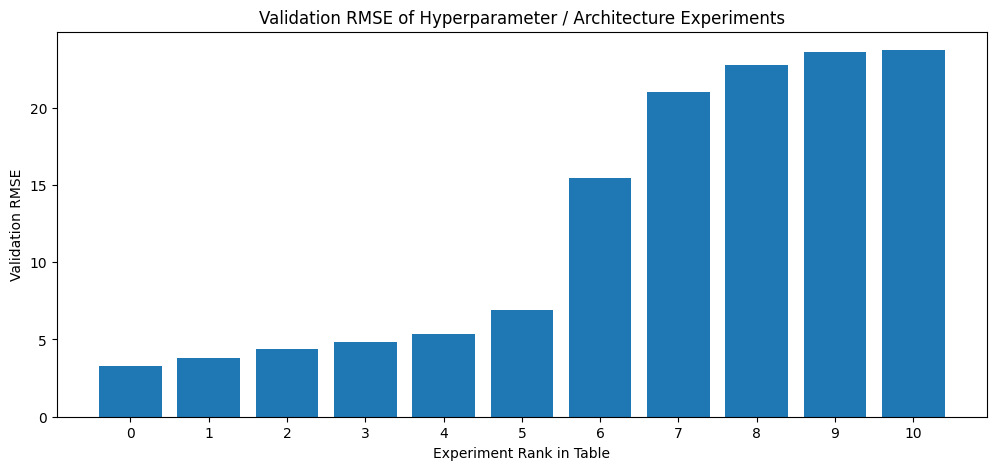

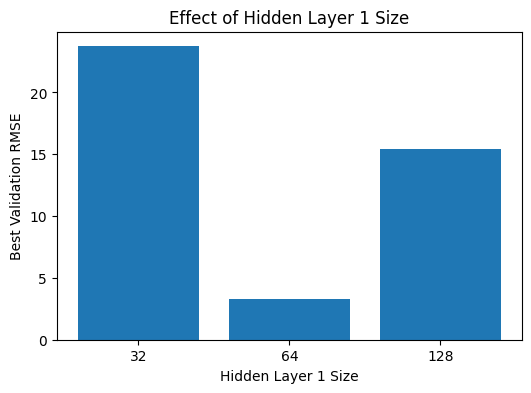

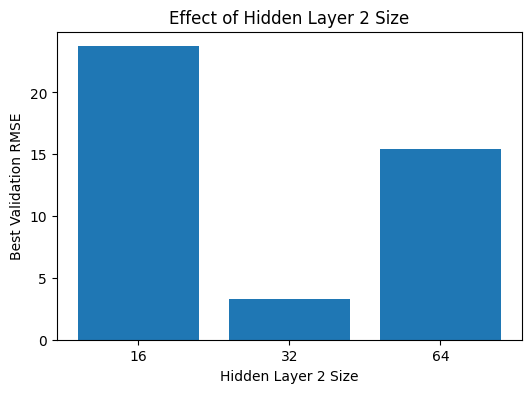

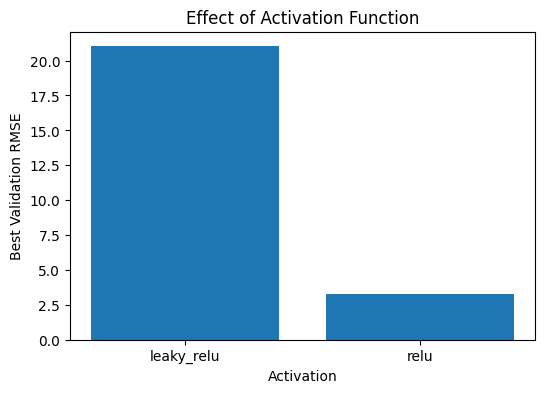

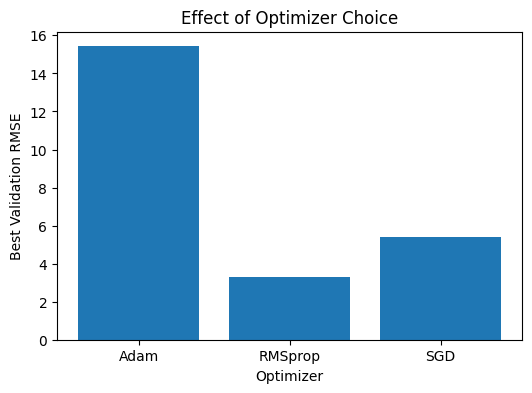

Epoch 1, Iteration 0, train_mse = 673.8257, val_rmse = 24.0595, val_mae = 23.0769
Epoch 2, Iteration 0, train_mse = 335.6708, val_rmse = 15.1816, val_mae = 13.7043
Epoch 3, Iteration 0, train_mse = 294.1816, val_rmse = 19.7941, val_mae = 16.4249
Epoch 4, Iteration 0, train_mse = 56.1719, val_rmse = 4.1400, val_mae = 3.1097
Epoch 5, Iteration 0, train_mse = 84.3186, val_rmse = 8.7948, val_mae = 7.9067
Epoch 6, Iteration 0, train_mse = 47.7412, val_rmse = 6.6642, val_mae = 5.7412
Epoch 7, Iteration 0, train_mse = 42.8815, val_rmse = 3.2686, val_mae = 2.6349
Epoch 8, Iteration 0, train_mse = 55.2986, val_rmse = 3.5845, val_mae = 2.7258
Epoch 9, Iteration 0, train_mse = 45.0392, val_rmse = 3.1759, val_mae = 2.3674
Epoch 10, Iteration 0, train_mse = 31.7291, val_rmse = 3.3798, val_mae = 2.6103
Epoch 11, Iteration 0, train_mse = 21.8115, val_rmse = 3.1556, val_mae = 2.4106
Epoch 12, Iteration 0, train_mse = 36.8847, val_rmse = 2.9419, val_mae = 2.1923
Epoch 13, Iteration 0, train_mse = 24.55

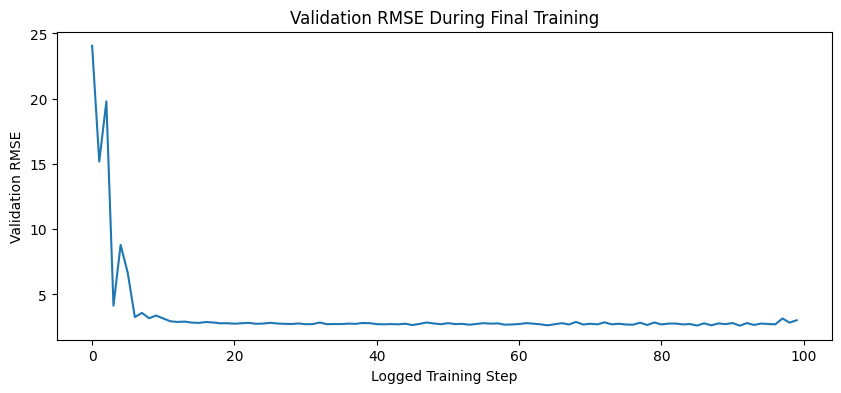

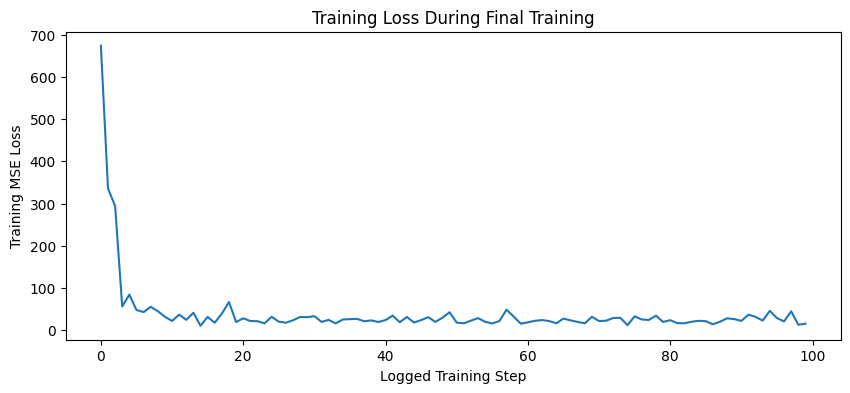


Best configuration used for final training:


,optimizer,batch_size,lr,weight_decay,dropout,hidden1,hidden2,activation
0,RMSprop,32,0.0005,0.00005,0.2,64,32,relu


Best validation RMSE achieved: 2.6018

Top 5 search results:


,optimizer,batch_size,lr,weight_decay,dropout,hidden1,hidden2,activation,stage,val_rmse,val_mae
0,RMSprop,32,0.0005,0.00010,0.20,64,32,relu,coarse,3.288467,2.577607
1,RMSprop,32,0.0005,0.00005,0.20,64,32,relu,fine,3.825104,2.927741
2,RMSprop,32,0.0005,0.00010,0.20,64,32,relu,fine,4.374732,3.374332
3,RMSprop,32,0.0004,0.00010,0.15,64,32,relu,fine,4.863554,3.694467
4,SGD,32,0.0100,0.00010,0.20,64,32,relu,coarse,5.383790,4.578702


In [ ]:
################################################################################
# TODO:
# Experiment with architectures, optimizers, and hyperparameters for Auto MPG
# regression. Select the best model on the validation set within 10 epochs.
# Use the test set only once at the very end.
################################################################################

import copy
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


# -----------------------------
# loaders
# -----------------------------
def make_loaders(batch_size):
    train_dataset_local = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset_local = TensorDataset(X_val_tensor, y_val_tensor)

    loader_train_local = DataLoader(
        train_dataset_local,
        batch_size=batch_size,
        shuffle=True
    )

    loader_val_local = DataLoader(
        val_dataset_local,
        batch_size=batch_size,
        shuffle=False
    )

    return loader_train_local, loader_val_local


# -----------------------------
# architecture choices
# -----------------------------
class AutoMPG_MLP(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=32, dropout=0.2, activation='relu'):
        super().__init__()

        def act_layer():
            if activation == 'relu':
                return nn.ReLU()
            elif activation == 'leaky_relu':
                return nn.LeakyReLU(0.1)
            elif activation == 'elu':
                return nn.ELU()
            else:
                raise ValueError(f"Unsupported activation: {activation}")

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            act_layer(),
            nn.Dropout(dropout),

            nn.Linear(hidden1, hidden2),
            act_layer(),
            nn.Dropout(dropout),

            nn.Linear(hidden2, 1)
        )

    def forward(self, x):
        return self.net(x)


# -----------------------------
# validation metric + optimizer helpers
# -----------------------------
def get_regression_metrics(loader, model):
    model.eval()
    total_squared_error = 0.0
    total_absolute_error = 0.0
    num_samples = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=dtype)
            y = y.to(device=device, dtype=dtype)

            preds = model(x)

            total_squared_error += ((preds - y) ** 2).sum().item()
            total_absolute_error += torch.abs(preds - y).sum().item()
            num_samples += y.size(0)

    mse = total_squared_error / num_samples
    rmse = mse ** 0.5
    mae = total_absolute_error / num_samples
    return rmse, mae


def make_optimizer(model, config):
    name = config["optimizer"]

    if name == "Adam":
        return optim.Adam(
            model.parameters(),
            lr=config["lr"],
            weight_decay=config["weight_decay"]
        )
    elif name == "SGD":
        return optim.SGD(
            model.parameters(),
            lr=config["lr"],
            momentum=0.9,
            nesterov=True,
            weight_decay=config["weight_decay"]
        )
    elif name == "RMSprop":
        return optim.RMSprop(
            model.parameters(),
            lr=config["lr"],
            momentum=0.9,
            weight_decay=config["weight_decay"]
        )
    else:
        raise ValueError(f"Unsupported optimizer: {name}")


# -----------------------------
# search training
# -----------------------------
def train_for_search(model, optimizer, loader_train_local, loader_val_local, epochs=3):
    model = model.to(device=device)
    loss_fn = nn.MSELoss()
    best_val_rmse = float("inf")

    for e in range(epochs):
        model.train()
        for x, y in loader_train_local:
            x = x.to(device=device, dtype=dtype)
            y = y.to(device=device, dtype=dtype)

            preds = model(x)
            loss = loss_fn(preds, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        val_rmse, _ = get_regression_metrics(loader_val_local, model)
        best_val_rmse = min(best_val_rmse, val_rmse)

    return best_val_rmse


# -----------------------------
# search 1
# -----------------------------
input_dim = X_train_tensor.shape[1]

coarse_search = [
    {"optimizer":"Adam",    "batch_size":32, "lr":1e-3,  "weight_decay":1e-4, "dropout":0.10, "hidden1":32,  "hidden2":16,  "activation":"relu"},
    {"optimizer":"Adam",    "batch_size":32, "lr":1e-3,  "weight_decay":1e-4, "dropout":0.20, "hidden1":64,  "hidden2":32,  "activation":"relu"},
    {"optimizer":"Adam",    "batch_size":32, "lr":1e-3,  "weight_decay":1e-4, "dropout":0.30, "hidden1":128, "hidden2":64,  "activation":"relu"},
    {"optimizer":"Adam",    "batch_size":32, "lr":1e-3,  "weight_decay":1e-4, "dropout":0.20, "hidden1":64,  "hidden2":32,  "activation":"leaky_relu"},
    {"optimizer":"Adam",    "batch_size":64, "lr":1e-3,  "weight_decay":1e-4, "dropout":0.20, "hidden1":64,  "hidden2":32,  "activation":"relu"},
    {"optimizer":"SGD",     "batch_size":32, "lr":1e-2,  "weight_decay":1e-4, "dropout":0.20, "hidden1":64,  "hidden2":32,  "activation":"relu"},
    {"optimizer":"RMSprop", "batch_size":32, "lr":5e-4,  "weight_decay":1e-4, "dropout":0.20, "hidden1":64,  "hidden2":32,  "activation":"relu"},
]

coarse_results = []
best_config = None
best_val_rmse = float("inf")

for i, config in enumerate(coarse_search):
    print(f"=== Coarse Experiment {i+1}/{len(coarse_search)} ===")
    print(config)

    loader_train_local, loader_val_local = make_loaders(config["batch_size"])

    candidate_model = AutoMPG_MLP(
        input_dim=input_dim,
        hidden1=config["hidden1"],
        hidden2=config["hidden2"],
        dropout=config["dropout"],
        activation=config["activation"]
    )

    candidate_optimizer = make_optimizer(candidate_model, config)

    val_rmse = train_for_search(
        candidate_model,
        candidate_optimizer,
        loader_train_local,
        loader_val_local,
        epochs=6
    )

    _, val_mae = get_regression_metrics(loader_val_local, candidate_model)

    result = config.copy()
    result["stage"] = "coarse"
    result["val_rmse"] = val_rmse
    result["val_mae"] = val_mae
    coarse_results.append(result)

    print(f"Validation RMSE: {val_rmse:.4f}, Validation MAE: {val_mae:.4f}\n")

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_config = config.copy()

print("Best coarse config:")
print(best_config)
print(f"Best coarse validation RMSE: {best_val_rmse:.4f}")


# -----------------------------
# search 2
# -----------------------------
fine_search = [
    {
        "optimizer": best_config["optimizer"],
        "batch_size": best_config["batch_size"],
        "lr": best_config["lr"] * 0.8,
        "weight_decay": best_config["weight_decay"],
        "dropout": max(0.0, best_config["dropout"] - 0.05),
        "hidden1": best_config["hidden1"],
        "hidden2": best_config["hidden2"],
        "activation": best_config["activation"]
    },
    {
        "optimizer": best_config["optimizer"],
        "batch_size": best_config["batch_size"],
        "lr": best_config["lr"],
        "weight_decay": best_config["weight_decay"],
        "dropout": best_config["dropout"],
        "hidden1": best_config["hidden1"],
        "hidden2": best_config["hidden2"],
        "activation": best_config["activation"]
    },
    {
        "optimizer": best_config["optimizer"],
        "batch_size": best_config["batch_size"],
        "lr": best_config["lr"] * 1.2,
        "weight_decay": best_config["weight_decay"],
        "dropout": best_config["dropout"],
        "hidden1": best_config["hidden1"],
        "hidden2": best_config["hidden2"],
        "activation": best_config["activation"]
    },
    {
        "optimizer": best_config["optimizer"],
        "batch_size": best_config["batch_size"],
        "lr": best_config["lr"],
        "weight_decay": best_config["weight_decay"] * 0.5,
        "dropout": best_config["dropout"],
        "hidden1": best_config["hidden1"],
        "hidden2": best_config["hidden2"],
        "activation": best_config["activation"]
    },
]

fine_results = []
best_fine_config = None
best_fine_val_rmse = float("inf")

for i, config in enumerate(fine_search):
    print(f"=== Fine Experiment {i+1}/{len(fine_search)} ===")
    print(config)

    loader_train_local, loader_val_local = make_loaders(config["batch_size"])

    candidate_model = AutoMPG_MLP(
        input_dim=input_dim,
        hidden1=config["hidden1"],
        hidden2=config["hidden2"],
        dropout=config["dropout"],
        activation=config["activation"]
    )

    candidate_optimizer = make_optimizer(candidate_model, config)

    val_rmse = train_for_search(
        candidate_model,
        candidate_optimizer,
        loader_train_local,
        loader_val_local,
        epochs=3
    )

    _, val_mae = get_regression_metrics(loader_val_local, candidate_model)

    result = config.copy()
    result["stage"] = "fine"
    result["val_rmse"] = val_rmse
    result["val_mae"] = val_mae
    fine_results.append(result)

    print(f"Validation RMSE: {val_rmse:.4f}, Validation MAE: {val_mae:.4f}\n")

    if val_rmse < best_fine_val_rmse:
        best_fine_val_rmse = val_rmse
        best_fine_config = config.copy()

print("Best fine config:")
print(best_fine_config)
print(f"Best fine validation RMSE: {best_fine_val_rmse:.4f}")


# -----------------------------
# summary table
# -----------------------------
search_results = pd.DataFrame(coarse_results + fine_results)
search_results = search_results.sort_values("val_rmse", ascending=True).reset_index(drop=True)

print("\nTop search results:")
display(search_results)

print("\nBest final selected config:")
print(best_fine_config)


# -----------------------------
# graphs
# -----------------------------
plt.figure(figsize=(12, 5))
plt.bar(range(len(search_results)), search_results["val_rmse"])
plt.xticks(range(len(search_results)), search_results.index, rotation=0)
plt.ylabel("Validation RMSE")
plt.xlabel("Experiment Rank in Table")
plt.title("Validation RMSE of Hyperparameter / Architecture Experiments")
plt.show()

hidden1_summary = search_results.groupby("hidden1", as_index=False)["val_rmse"].min()
plt.figure(figsize=(6, 4))
plt.bar(hidden1_summary["hidden1"].astype(str), hidden1_summary["val_rmse"])
plt.xlabel("Hidden Layer 1 Size")
plt.ylabel("Best Validation RMSE")
plt.title("Effect of Hidden Layer 1 Size")
plt.show()

hidden2_summary = search_results.groupby("hidden2", as_index=False)["val_rmse"].min()
plt.figure(figsize=(6, 4))
plt.bar(hidden2_summary["hidden2"].astype(str), hidden2_summary["val_rmse"])
plt.xlabel("Hidden Layer 2 Size")
plt.ylabel("Best Validation RMSE")
plt.title("Effect of Hidden Layer 2 Size")
plt.show()

activation_summary = search_results.groupby("activation", as_index=False)["val_rmse"].min()
plt.figure(figsize=(6, 4))
plt.bar(activation_summary["activation"], activation_summary["val_rmse"])
plt.xlabel("Activation")
plt.ylabel("Best Validation RMSE")
plt.title("Effect of Activation Function")
plt.show()

optimizer_summary = search_results.groupby("optimizer", as_index=False)["val_rmse"].min()
plt.figure(figsize=(6, 4))
plt.bar(optimizer_summary["optimizer"], optimizer_summary["val_rmse"])
plt.xlabel("Optimizer")
plt.ylabel("Best Validation RMSE")
plt.title("Effect of Optimizer Choice")
plt.show()


# -----------------------------
# final model training
# -----------------------------
loader_train, loader_val = make_loaders(best_fine_config["batch_size"])

model = AutoMPG_MLP(
    input_dim=input_dim,
    hidden1=best_fine_config["hidden1"],
    hidden2=best_fine_config["hidden2"],
    dropout=best_fine_config["dropout"],
    activation=best_fine_config["activation"]
)

optimizer = make_optimizer(model, best_fine_config)


def train_part34_save_best(model, optimizer, epochs=10):
    model = model.to(device=device)
    loss_fn = nn.MSELoss()
    best_val_rmse = float("inf")
    best_state = None
    training_history = []

    for e in range(epochs):
        model.train()
        for t, (x, y) in enumerate(loader_train):
            x = x.to(device=device, dtype=dtype)
            y = y.to(device=device, dtype=dtype)

            preds = model(x)
            loss = loss_fn(preds, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if t % print_every == 0:
                val_rmse, val_mae = get_regression_metrics(loader_val, model)

                training_history.append({
                    "epoch": e,
                    "iteration": t,
                    "loss": loss.item(),
                    "val_rmse": val_rmse,
                    "val_mae": val_mae
                })

                print(
                    f"Epoch {e+1}, Iteration {t}, "
                    f"train_mse = {loss.item():.4f}, "
                    f"val_rmse = {val_rmse:.4f}, "
                    f"val_mae = {val_mae:.4f}"
                )

                if val_rmse < best_val_rmse:
                    best_val_rmse = val_rmse
                    best_state = copy.deepcopy(model.state_dict())

    if best_state is not None:
        model.load_state_dict(best_state)

    print(f"\nBest validation RMSE during final training: {best_val_rmse:.4f}")
    return model, pd.DataFrame(training_history), best_val_rmse


# -----------------------------
# final run
# -----------------------------
model, training_history_df, best_validation_rmse = train_part34_save_best(model, optimizer, epochs=100)

best_model = model


# -----------------------------
# graphs
# -----------------------------
plt.figure(figsize=(10, 4))
plt.plot(training_history_df.index, training_history_df["val_rmse"])
plt.xlabel("Logged Training Step")
plt.ylabel("Validation RMSE")
plt.title("Validation RMSE During Final Training")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(training_history_df.index, training_history_df["loss"])
plt.xlabel("Logged Training Step")
plt.ylabel("Training MSE Loss")
plt.title("Training Loss During Final Training")
plt.show()


# -----------------------------
# summary table
# -----------------------------
print("\nBest configuration used for final training:")
best_config_df = pd.DataFrame([best_fine_config])
display(best_config_df)

print(f"Best validation RMSE achieved: {best_validation_rmse:.4f}")

print("\nTop 5 search results:")
display(search_results.head(5))

################################################################################
# END OF YOUR CODE
################################################################################


## Test set -- run this only once

Now that we've gotten a result we're happy with, we test our final model on the test set (which you should store in best_model). Think about how this compares to your validation set accuracy.

In [ ]:
# Test set -- run this only once

best_model = model
best_model.eval()

y_true_list = []
y_pred_list = []

with torch.no_grad():
    for x, y in loader_test:
        x = x.to(device=device, dtype=dtype)
        y = y.to(device=device, dtype=dtype)

        preds = best_model(x)

        y_true_list.append(y.cpu().numpy())
        y_pred_list.append(preds.cpu().numpy())

y_true = np.concatenate(y_true_list, axis=0).reshape(-1)
y_pred = np.concatenate(y_pred_list, axis=0).reshape(-1)

mse = np.mean((y_pred - y_true) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_pred - y_true))

ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - y_true.mean()) ** 2)
r2 = 1 - ss_res / ss_tot

print(f"Final test RMSE: {rmse:.4f}")
print(f"Final test MAE: {mae:.4f}")
print(f"Final test R^2: {r2:.4f}")


Final test RMSE: 2.3489
Final test MAE: 1.7412
Final test R^2: 0.8919


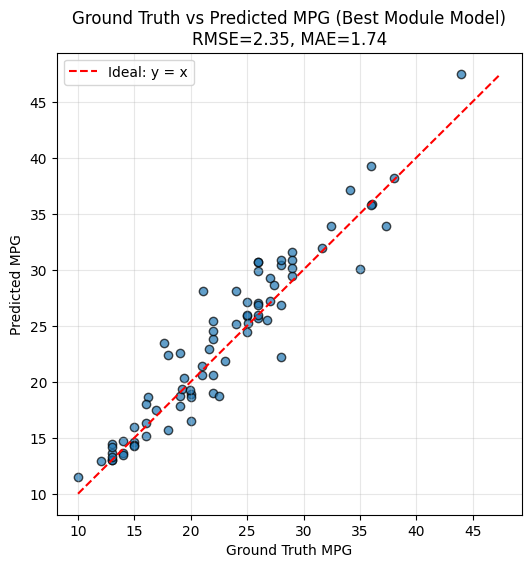

In [ ]:
# -----------------------------
# ground truth vs predicted plot
# -----------------------------
best_model.eval()

y_true_list = []
y_pred_list = []

with torch.no_grad():
    for x, y in loader_test:
        x = x.to(device=device, dtype=dtype)
        y = y.to(device=device, dtype=dtype)

        preds = best_model(x)

        y_true_list.append(y.cpu().numpy())
        y_pred_list.append(preds.cpu().numpy())

y_true = np.concatenate(y_true_list, axis=0).reshape(-1)
y_pred = np.concatenate(y_pred_list, axis=0).reshape(-1)

mse = np.mean((y_pred - y_true) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_pred - y_true))

plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.7, edgecolor='k')

min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal: y = x')

plt.xlabel("Ground Truth MPG")
plt.ylabel("Predicted MPG")
plt.title(f"Ground Truth vs Predicted MPG (Best Module Model)\nRMSE={rmse:.2f}, MAE={mae:.2f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
